In [1]:
# Install dependencies
%pip install torch torchvision "diffusers==0.30.*" transformers accelerate pillow "numpy<2"


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 17.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 60.3 MB/s eta 0:00:0000:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 KB 83.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 564.3/564.3 KB 92.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 789.9/789.9 KB 92.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.8/485.8 KB 86.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 KB 20.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 105.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 122.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
from diffusers import StableDiffusionXLPipeline

# Setup device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float16 if DEVICE == "cuda" else torch.float32
print(f"Using {DEVICE} with {DTYPE}")


/home/ubuntu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-10-01 20:45:26.402226: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-01 20:45:26.497937: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759351526.541050   11419 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759351526.553427   11419 cuda_blas.cc:1407] Unable to 

Using cuda with torch.float16


In [3]:
# Load model
pipe = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=DTYPE
).to(DEVICE)

if DEVICE == "cpu":
    pass  # Don't use model_cpu_offload on CPU
else:
    pipe.enable_model_cpu_offload()

print("Model loaded")


Loading pipeline components...: 100%|██████████| 7/7 [00:01<00:00,  5.61it/s]


Model loaded


100%|██████████| 20/20 [00:03<00:00,  6.20it/s]


Generated image size: (1024, 1024)


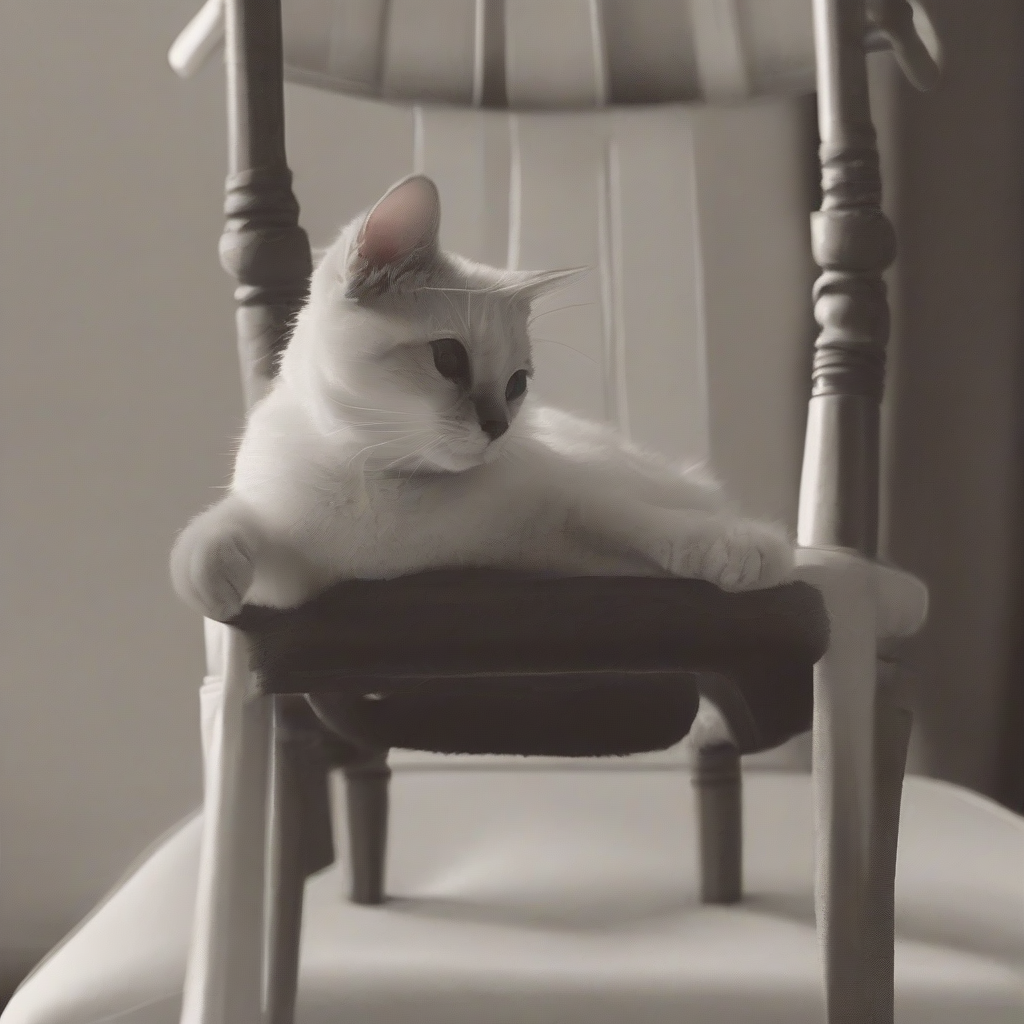

In [4]:
# Test basic image generation
prompt = "A cat sitting on a chair"

generator = torch.Generator(device=DEVICE).manual_seed(42)
steps = 20 if DEVICE == "cuda" else 20
height = 1024 if DEVICE == "cuda" else 1024
width = 1024 if DEVICE == "cuda" else 1024

with torch.no_grad():
    image = pipe(
        prompt=prompt,
        height=height,
        width=width,
        num_inference_steps=steps,
        generator=generator,
    ).images[0]

print(f"Generated image size: {image.size}")
image


100%|██████████| 20/20 [00:01<00:00, 11.11it/s]


Generated image with spectacles size: (1024, 1024)


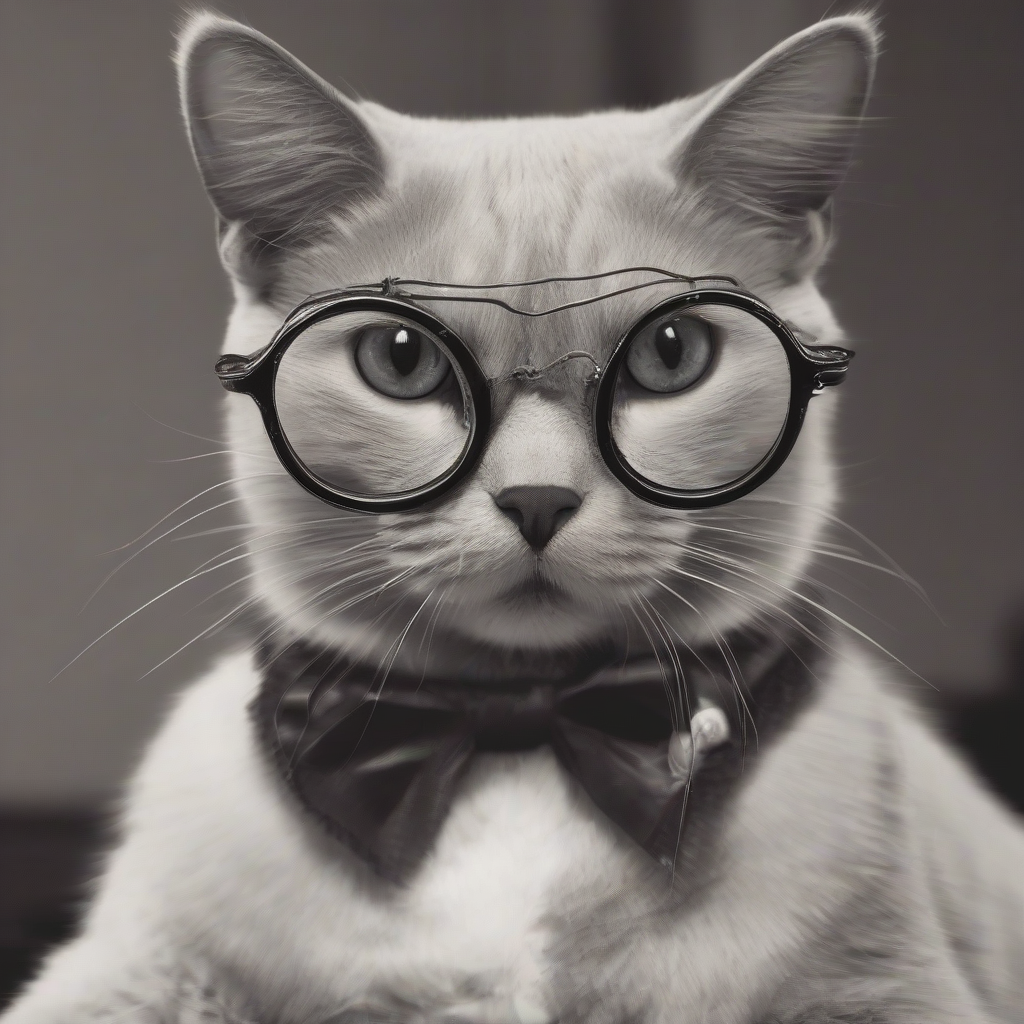

In [7]:
# Test spectacles prompt
prompt_with_spectacles = "a cat with spectacles"

generator2 = torch.Generator(device=DEVICE).manual_seed(42)  # Same seed

with torch.no_grad():
    image_with_specs = pipe(
        prompt=prompt_with_spectacles,
        height=height,
        width=width,
        num_inference_steps=steps,
        generator=generator2,
    ).images[0]

print(f"Generated image with spectacles size: {image_with_specs.size}")
image_with_specs


In [8]:
# Simple spectacles bias experiment
class SimpleTensorCapture:
    def __init__(self):
        self.data = None
        self.hook_handles = []
    
    def set(self, x):
        self.data = x
    
    def get(self):
        return self.data
    
    def register_hook(self, module, hook_fn):
        handle = module.register_forward_hook(hook_fn)
        self.hook_handles.append(handle)
        return handle
    
    def clear_hooks(self):
        for handle in self.hook_handles:
            handle.remove()
        self.hook_handles.clear()

# Create capture objects
text_capture = SimpleTensorCapture()
latent_capture = SimpleTensorCapture()

def text_hook(module, input, output):
    if hasattr(output, 'last_hidden_state'):
        text_capture.set(output.last_hidden_state.float().detach().cpu())

def latent_hook(module, input, output):
    if len(input) > 0 and isinstance(input[0], torch.Tensor):
        latents = input[0]
        if latents.dim() == 4:  # [B, C, H, W]
            latent_capture.set(latents.detach().cpu())

# Register hooks
text_handle = text_capture.register_hook(pipe.text_encoder, text_hook)
latent_handle = latent_capture.register_hook(pipe.unet, latent_hook)

print("Hooks registered")


Hooks registered


In [9]:
# Collect spectacles data
prompt_pairs = [
    ("A person reading a book", "A person wearing spectacles reading a book"),
    ("A scientist in a laboratory", "A scientist wearing spectacles in a laboratory"),
    ("A professor giving a lecture", "A professor wearing spectacles giving a lecture"),
    ("A person in a cafe", "A person wearing spectacles in a cafe"),
    ("A person in a library", "A person wearing spectacles in a library"),
    ("A person in a classroom", "A person wearing spectacles in a classroom"),

]

dataset = []

for base_prompt, spectacles_prompt in prompt_pairs:
    print(f"Processing: {base_prompt}")
    
    # Generate base image
    generator = torch.Generator(device=DEVICE).manual_seed(42)
    with torch.no_grad():
        base_image = pipe(prompt=base_prompt, height=height, width=width, 
                         num_inference_steps=steps, generator=generator).images[0]
    
    base_text = text_capture.get()
    base_latent = latent_capture.get()
    
    # Generate spectacles image
    generator = torch.Generator(device=DEVICE).manual_seed(42)
    with torch.no_grad():
        spectacles_image = pipe(prompt=spectacles_prompt, height=height, width=width,
                               num_inference_steps=steps, generator=generator).images[0]
    
    spectacles_text = text_capture.get()
    spectacles_latent = latent_capture.get()
    
    if all(x is not None for x in [base_text, base_latent, spectacles_text, spectacles_latent]):
        # Compute bias
        text_pooled = base_text.mean(dim=1).squeeze(0)  # [768]
        latent_bias = spectacles_latent.mean(dim=(0, 2, 3)) - base_latent.mean(dim=(0, 2, 3))  # [4]
        
        dataset.append({
            'text': text_pooled,
            'bias': latent_bias,
            'prompt': base_prompt
        })
        print(f"  Added sample: text {text_pooled.shape}, bias {latent_bias.shape}")

print(f"Dataset size: {len(dataset)}")


Processing: A person reading a book


100%|██████████| 20/20 [00:01<00:00, 10.87it/s]


  Added sample: text torch.Size([768]), bias torch.Size([4])
Processing: A scientist in a laboratory


100%|██████████| 20/20 [00:01<00:00, 10.93it/s]


  Added sample: text torch.Size([768]), bias torch.Size([4])
Processing: A professor giving a lecture


...

  Added sample: text torch.Size([768]), bias torch.Size([4])
Processing: A person in a library


100%|██████████| 20/20 [00:01<00:00, 10.79it/s]


  Added sample: text torch.Size([768]), bias torch.Size([4])
Processing: A person in a classroom


100%|██████████| 20/20 [00:01<00:00, 10.72it/s]


  Added sample: text torch.Size([768]), bias torch.Size([4])
Dataset size: 6


In [36]:
#datset oadijng fro creating the mapping obejcts and training the mapping
# Simple dataset loading function
from datasets import load_dataset
import json

def load_prompts_from_hf(dataset_name="jackyhate/text-to-image-2M", json_column='json', max_samples=None):
    """
    Load prompts from a Hugging Face dataset
    
    Args:
        dataset_name: Name of the Hugging Face dataset
        json_column: Name of the column containing JSON data (default: 'json')
        max_samples: Maximum number of samples to load (default: None for all)
    
    Returns:
        List of prompt strings
    """
    # Load dataset
    dataset = load_dataset(dataset_name)
    dataset = dataset['train']['json']

    
    prompts = []
    
    # Extract prompts from JSON column
    for item in dataset:
        prompt = item['prompt']
        prompts.append(prompt)
    
    print(f"Loaded {len(prompts)} prompts from {dataset_name}")
    return prompts
    

# Usage example:
prompts = load_prompts_from_hf("jackyhate/text-to-image-2M", max_samples=len(dataset))


Loaded 2300793 prompts from jackyhate/text-to-image-2M


In [37]:
prompts[0]

"A promotional image for a crampon storage bag with a group of hikers in the background. The bag is prominently displayed in the foreground, with a large, detailed image of the bag's mesh design and a smaller image of the bag's orange and blue color scheme. The text 'CRAMPON STORAGE BAG' is displayed at the top, along with the tagline 'Premium Material, Practical Design, Easy to Use'. The background features a snowy mountain landscape with hikers in various colors of jackets and backpacks."

In [19]:
# Fixed training with gradient clipping and better initialization
if len(dataset) > 0:
    # Prepare data
    text_tensor = torch.stack([d['text'] for d in dataset])
    bias_tensor = torch.stack([d['bias'] for d in dataset])
    
    print(f"Input data stats:")
    print(f"  Text tensor: mean={text_tensor.mean().item():.6f}, std={text_tensor.std().item():.6f}")
    print(f"  Bias tensor: mean={bias_tensor.mean().item():.6f}, std={bias_tensor.std().item():.6f}")
    
    # Create a more stable mapper
    class StableMapper(nn.Module):
        def __init__(self, text_dim=768, latent_dim=4):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(text_dim, 128),  # Smaller hidden layer
                nn.LayerNorm(128),
                nn.ReLU(),
                nn.Dropout(0.2),
                nn.Linear(128, latent_dim)
            )
            # Careful weight initialization
            self._init_weights()

        def forward(self, x):
            return self.net(x)
        
        def _init_weights(self):
            for module in self.modules():
                if isinstance(module, nn.Linear):
                    nn.init.normal_(module.weight, mean=0.0, std=0.01)  # Small std
                    nn.init.zeros_(module.bias)
    
    # Train with more conservative settings
    mapper = StableMapper().to(DEVICE, dtype=DTYPE)
    optimizer = torch.optim.Adam(mapper.parameters(), lr=1e-5)  # Much smaller LR
    criterion = nn.MSELoss()
    
    mapper.train()
    for epoch in range(1):
        optimizer.zero_grad()
        
        predicted = mapper(text_tensor.to(DEVICE, dtype=DTYPE))
        loss = criterion(predicted, bias_tensor.to(DEVICE, dtype=DTYPE))
        
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"NaN/Inf detected at epoch {epoch}")
            break
            
        loss.backward()
        
        # Gradient clipping - much more aggressive
        torch.nn.utils.clip_grad_norm_(mapper.parameters(), max_norm=0.01)
        
        optimizer.step()
        
        if epoch % 20 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.6f}")
    
    print("Training completed successfully!")
    
    # Test the trained mapper
    mapper.eval()
    with torch.no_grad():
        test_pred = mapper(text_tensor.to(DEVICE, dtype=DTYPE))
        print(f"Final predictions - NaN: {torch.isnan(test_pred).any()}, Inf: {torch.isinf(test_pred).any()}")
        
else:
    print("No data to train on")


Input data stats:
  Text tensor: mean=-0.111714, std=0.937751
  Bias tensor: mean=0.006321, std=0.172363
Epoch 0: Loss = 0.032257
Training completed successfully!
Final predictions - NaN: True, Inf: False


In [ ]:
#Let's make parse the dataset to get text and latent pairs thar we cab train mappers on
# Collect spectacles data
prompt_pairs = [
    ("A person reading a book", "A person wearing spectacles reading a book"),
    ("A scientist in a laboratory", "A scientist wearing spectacles in a laboratory"),
    ("A professor giving a lecture", "A professor wearing spectacles giving a lecture"),
    ("A person in a cafe", "A person wearing spectacles in a cafe"),
    ("A person in a library", "A person wearing spectacles in a library"),
    ("A person in a classroom", "A person wearing spectacles in a classroom"),

]

dataset = []

for base_prompt, spectacles_prompt in prompt_pairs:
    print(f"Processing: {base_prompt}")
    
    # Generate base image
    generator = torch.Generator(device=DEVICE).manual_seed(42)
    with torch.no_grad():
        base_image = pipe(prompt=base_prompt, height=height, width=width, 
                         num_inference_steps=steps, generator=generator).images[0]
    
    base_text = text_capture.get()
    base_latent = latent_capture.get()
    
    # Generate spectacles image
    generator = torch.Generator(device=DEVICE).manual_seed(42)
    with torch.no_grad():
        spectacles_image = pipe(prompt=spectacles_prompt, height=height, width=width,
                               num_inference_steps=steps, generator=generator).images[0]
    
    spectacles_text = text_capture.get()
    spectacles_latent = latent_capture.get()
    
    if all(x is not None for x in [base_text, base_latent, spectacles_text, spectacles_latent]):
        # Compute bias
        text_pooled = base_text.mean(dim=1).squeeze(0)  # [768]
        latent_bias = spectacles_latent.mean(dim=(0, 2, 3)) - base_latent.mean(dim=(0, 2, 3))  # [4]
        
        dataset.append({
            'text': text_pooled,
            'bias': latent_bias,
            'prompt': base_prompt
        })
        print(f"  Added sample: text {text_pooled.shape}, bias {latent_bias.shape}")

print(f"Dataset size: {len(dataset)}")

In [20]:
# Test the mapper
test_prompt = "A young woman working on her laptop"

# Generate base image and get text embedding
generator = torch.Generator(device=DEVICE).manual_seed(123)
with torch.no_grad():
    base_image = pipe(prompt=test_prompt, height=height, width=width,
                     num_inference_steps=steps, generator=generator).images[0]

text_embedding = text_capture.get()
base_latent = latent_capture.get()

if text_embedding is not None and base_latent is not None:
    # Get pooled text embedding
    text_pooled = text_embedding.mean(dim=1).squeeze(0)
    
    # Predict spectacles bias
    mapper.eval()
    with torch.no_grad():
        predicted_bias = mapper(text_pooled.to(DEVICE))
    
    print(f"Test prompt: {test_prompt}")
    print(f"Predicted spectacles bias: {predicted_bias.detach().cpu().numpy()}")
    print(f"Bias magnitude: {torch.norm(predicted_bias).item():.6f}")
    
    # Generate comparison image with explicit spectacles
    generator2 = torch.Generator(device=DEVICE).manual_seed(123)
    with torch.no_grad():
        spectacles_image = pipe(prompt=f"{test_prompt}, wearing spectacles", 
                              height=height, width=width, num_inference_steps=steps, 
                              generator=generator2).images[0]
    
    print("Base image:")
    base_image
    print("With spectacles:")
    spectacles_image
    
else:
    print("Failed to capture embeddings")

100%|██████████| 20/20 [00:01<00:00, 10.77it/s]


RuntimeError: mat1 and mat2 must have the same dtype, but got Float and Half